In [1]:
from phd_parser.xps.casaxps import read_export, split_lines, extract_lines, parse_metadata_lines, parse_data_lines
import os
import matplotlib.pyplot as plt

In [2]:
MOCK_FILE_PATH = r"C:\Users\jsommer1\Downloads\testtt_SK-0004_1_0019.txt"

In [3]:
lines = extract_lines(MOCK_FILE_PATH)
metadata_lines, header_line, data_lines = split_lines(lines)

In [4]:
metadata_lines

['Cycle 0:SK-0004_1:C1s Scan\n',
 '\tCharacteristic Energy eV\t1.486680e+03\tAcquisition Time s\t5.000000e-01\n',
 'Name\t\tC 1s\t\n',
 'Position\t\t284.80\t\n',
 'FWHM\t\t2.30\t\n',
 'Area\t\t17196.53\t\n',
 'Lineshape\t\tLA(50)\t\n']

In [5]:
xps = read_export(MOCK_FILE_PATH)

In [6]:
xps["meta"]

{'info_0': 'Cycle 0:SK-0004_1:C1s Scan',
 'Characteristic Energy eV': [1486.68],
 'Acquisition Time s': [0.5],
 'Name': ['C 1s'],
 'Position': [284.8],
 'FWHM': [2.3],
 'Area': [17196.53],
 'Lineshape': ['LA(50)'],
 'peaks': [{'Characteristic Energy eV': 1486.68,
   'Acquisition Time s': 0.5,
   'Name': 'C 1s',
   'Position': 284.8,
   'FWHM': 2.3,
   'Area': 17196.53,
   'Lineshape': 'LA(50)'}],
 'type': 'singlet',
 'filename': 'testtt_SK-0004_1_0019.txt'}

In [7]:
be = xps["binding energy"]

In [9]:
xps["meta"]

{'info_0': 'Cycle 0:SK-0004_1:C1s Scan',
 'Characteristic Energy eV': [1486.68],
 'Acquisition Time s': [0.5],
 'Name': ['C 1s'],
 'Position': [284.8],
 'FWHM': [2.3],
 'Area': [17196.53],
 'Lineshape': ['LA(50)'],
 'peaks': [{'Characteristic Energy eV': 1486.68,
   'Acquisition Time s': 0.5,
   'Name': 'C 1s',
   'Position': 284.8,
   'FWHM': 2.3,
   'Area': 17196.53,
   'Lineshape': 'LA(50)'}],
 'type': 'singlet',
 'filename': 'testtt_SK-0004_1_0019.txt'}

In [10]:
be.head()

,B.E.,CPS,C 1s,Background CPS,Envelope CPS
0,298.08,3994.40,4001.068,3994.40,4001.068
1,297.98,3945.22,3951.991,3945.22,3951.991
2,297.88,3999.06,4005.936,3999.06,4005.936
3,297.78,3761.90,3768.884,3761.90,3768.884
4,297.68,3888.98,3896.074,3888.98,3896.074


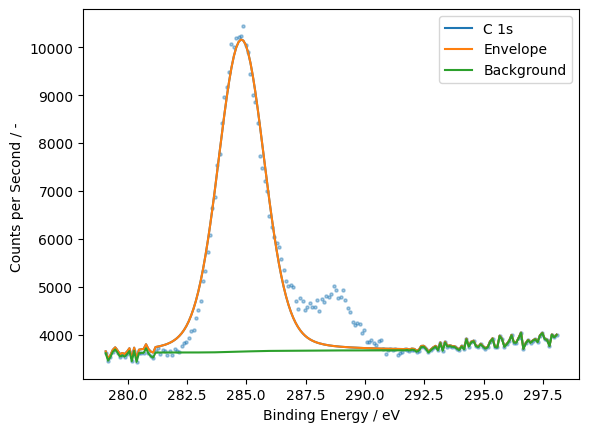

In [12]:
fig, ax = plt.subplots()

ax.scatter(be["B.E."], be["CPS"], s = 5, alpha = 0.4)
ax.set_xlabel("Binding Energy / eV")
ax.set_ylabel("Counts per Second / - ")
for peak in xps["meta"]["Name"]:
    ax.plot(be["B.E."], be[peak], label = peak)
ax.plot(be["B.E."], be["Envelope CPS"], label = "Envelope")
ax.plot(be["B.E."], be["Background CPS"], label = "Background")
ax.legend()

In [ ]:
metadata_lines, header_line, data_lines = split_lines(extract_lines(MOCK_FILE_PATH))

In [ ]:
parse_metadata_lines(metadata_lines)

{'info_0': 'Cycle 0:SK_0001_1:C1s Scan',
 'Characteristic Energy eV': 1486.68,
 'Acquisition Time s': 0.5,
 'Name': 'C 1s',
 'Position': 284.81,
 'FWHM': 2.66,
 'Area': 14231.34,
 'Lineshape': 'LA(50)'}

In [ ]:
df_ke, df_be = parse_data_lines(data_lines, header_line=header_line)

In [ ]:
df_be.head()

,B.E.,CPS,C 1s,Background CPS,Envelope CPS
0,298.08,2529.12,2535.549,2529.12,2535.549
1,297.98,2509.32,2515.849,2509.32,2515.849
2,297.88,2613.36,2619.991,2613.36,2619.991
3,297.78,2514.36,2521.095,2514.36,2521.095
4,297.68,2567.22,2574.062,2567.22,2574.062


In [ ]:
plt.plot(df_ke["B.E."], df_ke["CPS"])

KeyError: 'B.E.'